# Sound Separation

In [21]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from IPython.display import display, Markdown
import functional as pyfn
import yaml
import librosa
import IPython
import matplotlib.pyplot as plt
from returns.result import Result, safe, Failure, Success
from returns.pipeline import flow
from returns.pointfree import bind

sys.path.insert(0, os.path.abspath('..'))

# Local imports from current directory - auto reload.
# Any changes you make to train.py will appear automatically.
%load_ext autoreload
%autoreload 2

from dataprocess.cwt.scalogram import plot_all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
ROOT_DIR = Path("../ext-data/presentation_data/")
META_FN = "meta.yaml"


In [23]:
@dataclass
class Meta:
    title: str
    src_cnt: int
    has_noise: bool
    mix_fn: Path
    s1_fn: Path
    s2_fn: Path
    s3_fn: Path | None
    est_s1_fn: Path
    est_s2_fn: Path
    est_s3_fn: Path | None
    noise_fn: Path | None
    

In [24]:
def load_meta(fp: Path) -> Result[Meta, Exception]:
    with open(fp, 'r') as file:
        yaml_data = yaml.load(file, Loader=yaml.FullLoader)
        title = yaml_data["title"]
        src_cnt = yaml_data["src_cnt"]
        noise = yaml_data["has_noise"]
        mix_fn = yaml_data["src_mappings"]["mix"]
        s1_fn = yaml_data["src_mappings"]["s1"]
        s2_fn = yaml_data["src_mappings"]["s2"]
        est_s1_fn = yaml_data["src_mappings"]["est_s1"]
        est_s2_fn = yaml_data["src_mappings"]["est_s2"]

        fn_list = [ mix_fn, s1_fn, s2_fn, est_s1_fn, est_s2_fn ]

        noise_fn = None
        if noise:
            noise_fn = yaml_data["src_mappings"]["noise"]
            fn_list.append(noise_fn)

        s3_fn, est_s3_fn = None, None
        if src_cnt == 3:
            s3_fn = yaml_data["src_mappings"]["s3"]
            est_s3_fn = yaml_data["src_mappings"]["est_s3"]
            fn_list.extend([s3_fn, est_s3_fn])

        parent = fp.parent
        ret = pyfn.seq(fn_list).filter(lambda f: not (parent / f).exists())
        if ret.non_empty():
            return Failure(Exception(ret.make_string("\n")))
        
        return Success(Meta(
            title, src_cnt, noise, parent / mix_fn, parent / s1_fn,
            parent / s2_fn, parent / s3_fn if s3_fn else None,
            parent / est_s1_fn, parent / est_s2_fn,
            parent / est_s3_fn if est_s3_fn else None,
            parent / noise_fn if noise_fn else None
            ))
        

@safe
def src_plot(fp: Path) -> str:
    d, sr = librosa.load(fp, sr=None)
    display(IPython.display.Audio(data=d, rate=sr))

    plot_all(d, sr=sr, out_fn=None, threshold=-60, show_scale=True)
    plt.show()

    return "good"

    
def plot(meta: Meta) -> Result[str, Exception]:
    print(meta)
    display(Markdown(f"## {meta.title}"))

    display(Markdown("### Mix sound"))
    src_plot(meta.mix_fn)

    display(Markdown("### Source one sound"))
    src_plot(meta.s1_fn)
    # d2, sr2 = librosa.load(meta.s1_fn, sr=None)
    # display(IPython.display.Audio(data=d2, rate=sr2))

    # plot_all(d2, sr=sr2, out_fn=None, threshold=-60, show_scale=True)
    # plt.show()

    display(Markdown("### Estimated one sound"))
    src_plot(meta.est_s1_fn)

    # d3, sr3 = librosa.load(meta.est_s1_fn, sr=None)
    # display(IPython.display.Audio(data=d3, rate=sr3))

    # plot_all(d3, sr=sr3, out_fn=None, threshold=-60, show_scale=True)
    # plt.show()

    return Success("plot good")

def process(in_dir: Path) -> Result[str, Exception]:
    return flow(
        in_dir / META_FN,
        load_meta,
        bind(plot),
    )
    

Meta(title='A mix of two grasshoppers in the same family without drone noise', src_cnt=2, has_noise=False, mix_fn=PosixPath('../ext-data/presentation_data/mix2-gh-gh-aug-clean/mix.wav'), s1_fn=PosixPath('../ext-data/presentation_data/mix2-gh-gh-aug-clean/s1.wav'), s2_fn=PosixPath('../ext-data/presentation_data/mix2-gh-gh-aug-clean/s2.wav'), s3_fn=None, est_s1_fn=PosixPath('../ext-data/presentation_data/mix2-gh-gh-aug-clean/est_s1.wav'), est_s2_fn=PosixPath('../ext-data/presentation_data/mix2-gh-gh-aug-clean/est_s2.wav'), est_s3_fn=None, noise_fn=None)


## A mix of two grasshoppers in the same family without drone noise

### Mix sound

N: 88200


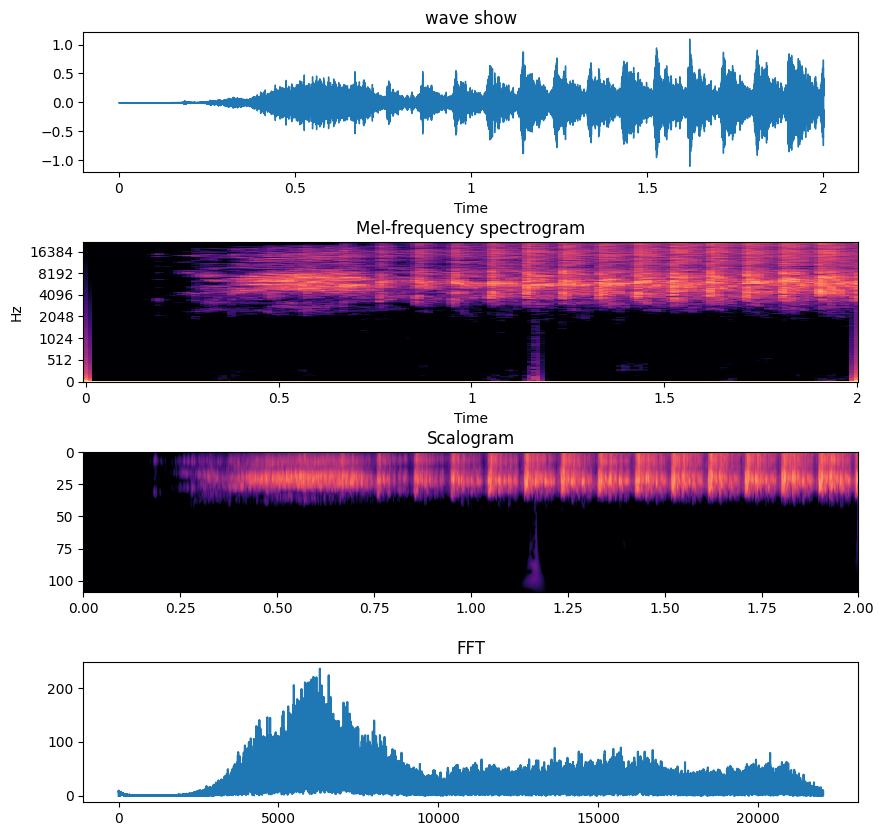

### Source one sound

N: 88200


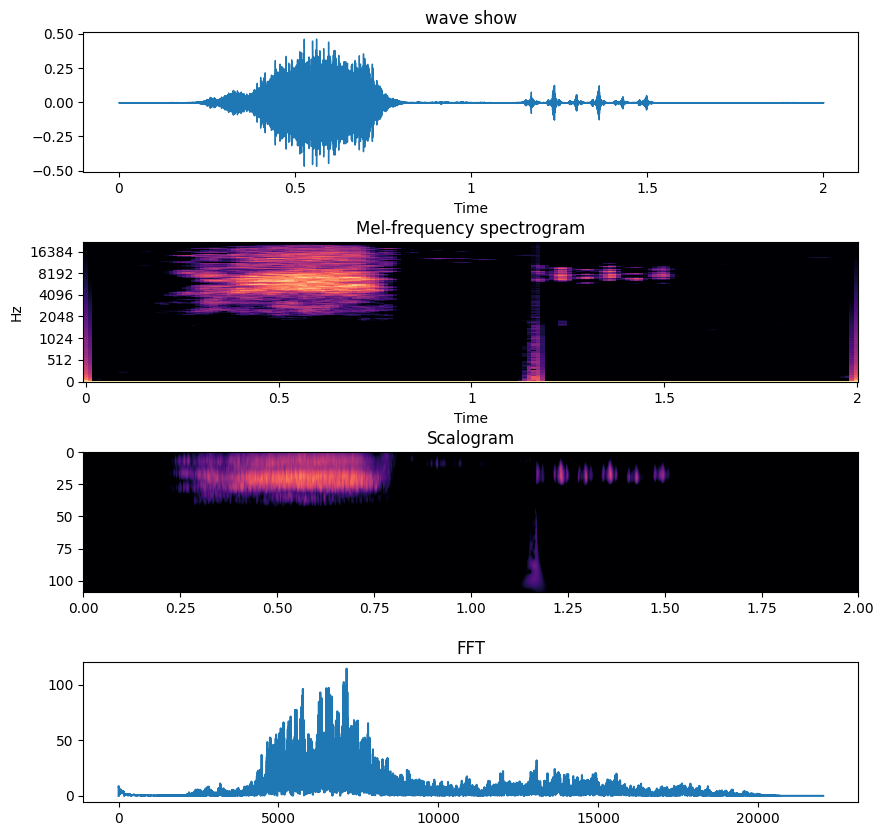

### Estimated one sound

N: 88200


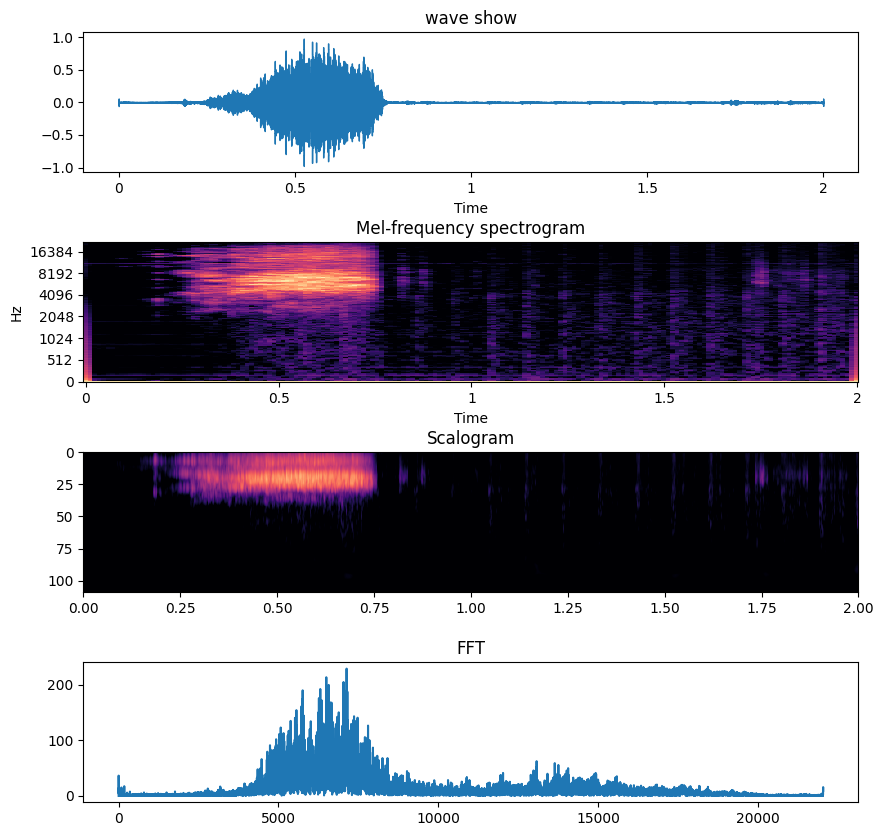

Meta(title='A mix of grasshoppers, bird and cricket with drone noise', src_cnt=3, has_noise=True, mix_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0.wav'), s1_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_s1.wav'), s2_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_s2.wav'), s3_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_s3.wav'), est_s1_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_est_s1-k8s4.wav'), est_s2_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_est_s2-k8s4.wav'), est_s3_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_est_s3-k8s4.wav'), noise_fn=PosixPath('../ext-data/presentation_data/mix3-gh-bird-cricket-noise/mix_0_noise.wav'))


## A mix of grasshoppers, bird and cricket with drone noise

### Mix sound

N: 88200


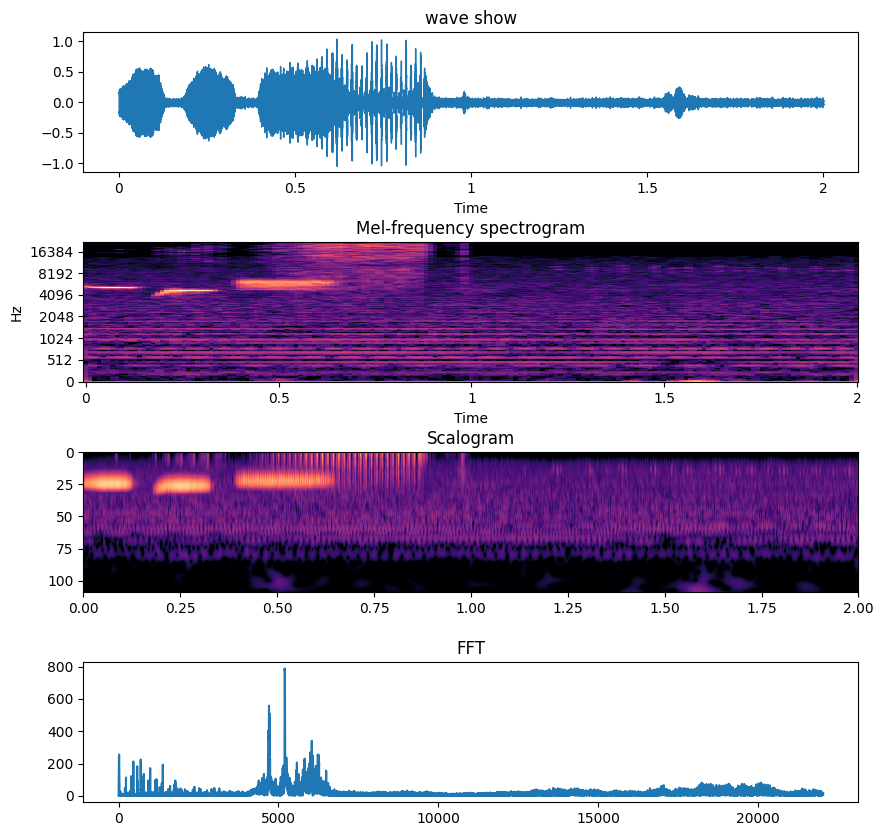

### Source one sound

N: 88200


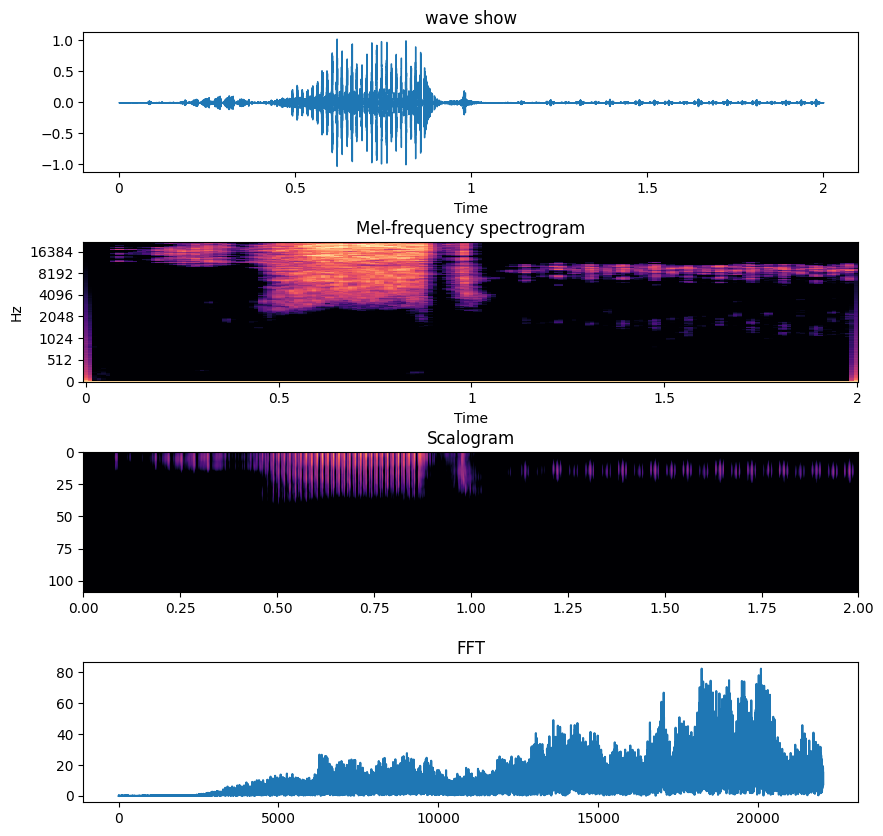

### Estimated one sound

N: 88200


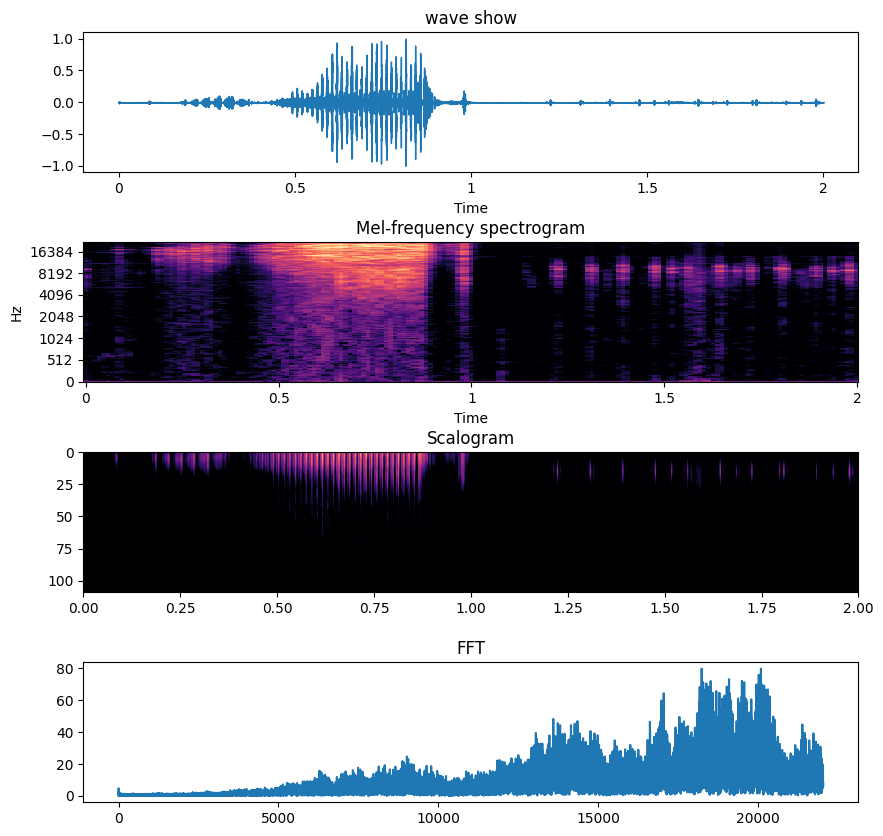

In [25]:

all_mix = ROOT_DIR.glob("mix*")

mix_dirs = pyfn.seq(all_mix).filter(lambda d: d.is_dir()).list()
# print(mix_dirs)
pyfn.seq(mix_dirs).for_each(process)
#print(process(mix_dirs[1]))
